In [1]:
# Base
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
import torch
import torchinfo

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


Število slik:          800
Interval širine slik:  [1116, 2040]
Interval višine slik:  [648, 2040]
Povprečna širina slik: 1971.51 +- 203.28
Povprečna višina slik: 1435.17 +- 251.57


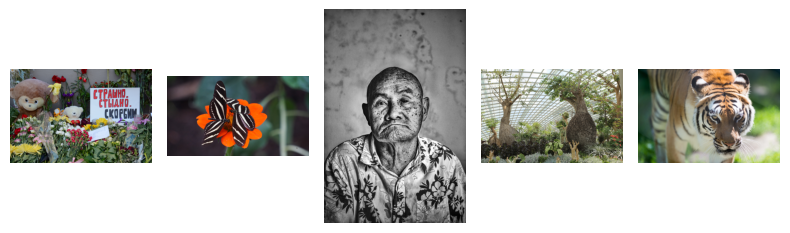

In [2]:
# DIV2K
path = "datasets/DIV2K/train/"

img_path_list = [os.path.join(path, name) for name in os.listdir(path)]

widths = []
heights = []
for img_path in img_path_list:
    with PIL.Image.open(img_path) as img:
        width, height = img.size
        widths.append(width)
        heights.append(height)

print(f"Število slik:          {len(img_path_list)}")
print(f"Interval širine slik:  [{np.min(widths)}, {np.max(widths)}]")
print(f"Interval višine slik:  [{np.min(heights)}, {np.max(heights)}]")
print(f"Povprečna širina slik: {np.mean(widths) :.2f} +- {np.std(widths) :.2f}")
print(f"Povprečna višina slik: {np.mean(heights) :.2f} +- {np.std(heights) :.2f}")

indices = np.random.default_rng().choice(len(img_path_list), 5, replace=False)

_, axes = plt.subplots(1, 5, figsize=(8, 3), squeeze=False)
for c in range(axes.shape[1]):
    img_path = img_path_list[indices[c]]
    with PIL.Image.open(img_path) as img:
        axes[0, c].imshow(img)
        axes[0, c].axis("off")
            
plt.tight_layout()

#### Generator slik

In [3]:
from torch.utils import data

# Generator in nalaganje podatkovnih zbirk
from dataset import data_generator, load_dataset

# Argumenti
batch_size = 64
img_size = 256

# Učna podatkovna zbirka
train_dataset_imgs = load_dataset("datasets/DIV2K/train/")

train_dataset = data_generator(train_dataset_imgs, img_size, 1024)
train_data_loader = data.DataLoader(train_dataset, batch_size=batch_size, pin_memory=True)

# Testna podatkovna zbirka
# TRAIN-TEST SPLIT!!
test_dataset = data_generator(train_dataset_imgs, img_size, 100)
test_data_loader = data.DataLoader(test_dataset, batch_size=1, pin_memory=True)

#### Testiranje generiranja

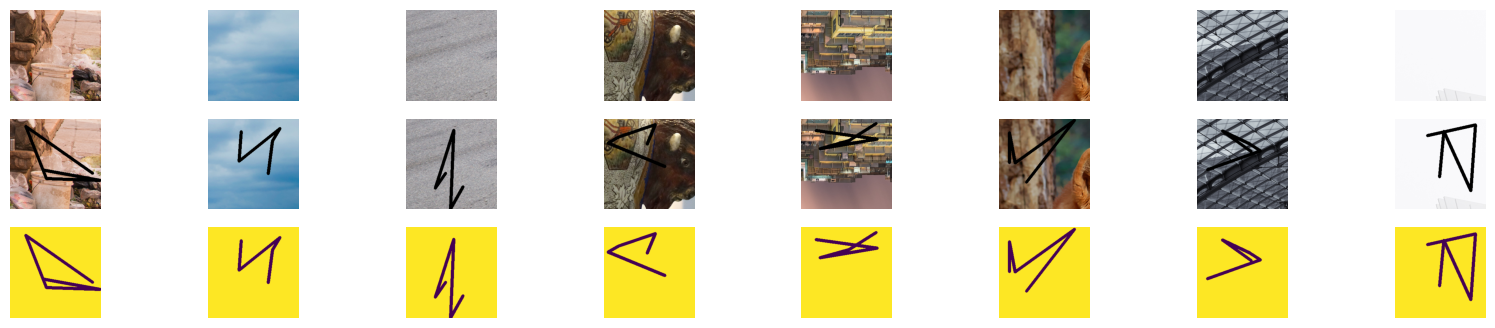

In [4]:
# Klic ene iteracije generatorja
img, img_masked, mask = next(iter(train_data_loader))

_, axes = plt.subplots(3, 8, figsize=(20, 4))
for i in range(0, 8):
    # Izris slik
    axes[0, i].imshow(torch.moveaxis(img[i], 0, 2))
    axes[0, i].axis("off")

    # Izris maskiranih slik
    axes[1, i].imshow(torch.moveaxis(img_masked[i], 0, 2))
    axes[1, i].axis("off")

    # Izris maske
    axes[2, i].imshow(torch.moveaxis(mask[i], 0, 2))
    axes[2, i].axis("off")

In [ ]:
# Nevronska mreža
from neural_network import *

# Model
model = PartialUNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), 1e-4)
model_file_name = f"model_test.pt"

input_img = torch.randn(1, 3, img_size, img_size).to(device)
input_mask = torch.ones(1, 1, img_size, img_size).to(device)

print(torchinfo.summary(model, input_data=(input_img, input_mask), depth=5))

Layer (type:depth-idx)                   Output Shape              Param #
PartialUNet                              [1, 3, 256, 256]          --
├─PartialBlock: 1-1                      [1, 32, 256, 256]         --
│    └─PartialConv2d: 2-1                [1, 32, 256, 256]         --
│    │    └─Conv2d: 3-1                  [1, 32, 256, 256]         896
│    └─BatchNorm2d: 2-2                  [1, 32, 256, 256]         64
├─PartialBlock: 1-2                      [1, 64, 128, 128]         --
│    └─PartialConv2d: 2-3                [1, 64, 128, 128]         --
│    │    └─Conv2d: 3-2                  [1, 64, 128, 128]         18,496
│    └─BatchNorm2d: 2-4                  [1, 64, 128, 128]         128
├─PartialBlock: 1-3                      [1, 128, 64, 64]          --
│    └─PartialConv2d: 2-5                [1, 128, 64, 64]          --
│    │    └─Conv2d: 3-3                  [1, 128, 64, 64]          73,856
│    └─BatchNorm2d: 2-6                  [1, 128, 64, 64]          256
├─Pa

In [6]:
# Učenje
epochs = 50

# Beleženje zgodovine
history = {"train_loss": []}

model.to(device)
nn_train(model, train_data_loader, epochs, optimizer, history)

# Shranjevanje modela
torch.save(model, model_file_name)

Epoch: [1/50] | Train Loss: 0.7446 | LR: 0.000100
Epoch: [2/50] | Train Loss: 0.6277 | LR: 0.000100
Epoch: [3/50] | Train Loss: 0.3876 | LR: 0.000100
Epoch: [4/50] | Train Loss: 0.3173 | LR: 0.000100
Epoch: [5/50] | Train Loss: 0.3070 | LR: 0.000100
Epoch: [6/50] | Train Loss: 0.2960 | LR: 0.000100
Epoch: [7/50] | Train Loss: 0.2663 | LR: 0.000100
Epoch: [8/50] | Train Loss: 0.2333 | LR: 0.000100
Epoch: [9/50] | Train Loss: 0.2243 | LR: 0.000100
Epoch: [10/50] | Train Loss: 0.2211 | LR: 0.000100
Epoch: [11/50] | Train Loss: 0.2083 | LR: 0.000100
Epoch: [12/50] | Train Loss: 0.2112 | LR: 0.000100
Epoch: [13/50] | Train Loss: 0.2109 | LR: 0.000100
Epoch: [14/50] | Train Loss: 0.2058 | LR: 0.000100
Epoch: [15/50] | Train Loss: 0.2098 | LR: 0.000100
Epoch: [16/50] | Train Loss: 0.2044 | LR: 0.000100
Epoch: [17/50] | Train Loss: 0.2030 | LR: 0.000100
Epoch: [18/50] | Train Loss: 0.1988 | LR: 0.000100
Epoch: [19/50] | Train Loss: 0.1962 | LR: 0.000100
Epoch: [20/50] | Train Loss: 0.2005 | LR

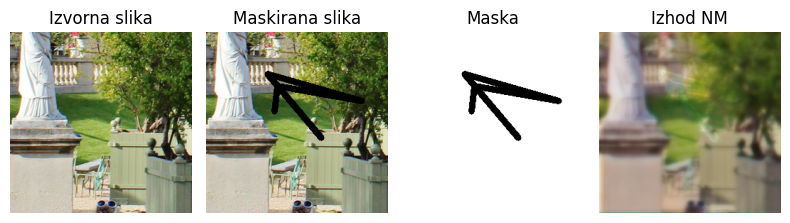

In [ ]:
# Vizualizacija
model.eval()
image, masked, mask = next(iter(test_data_loader))
image, masked, mask = image.to(device), masked.to(device), mask.to(device)

with torch.no_grad():
    pred, _ = model(masked, mask)

image = image.detach().cpu()
masked = masked.detach().cpu()
mask = mask.detach().cpu()
pred = pred.detach().cpu()

plt.figure(figsize=(8, 12))

# Izvorna slika
ax = plt.subplot(1, 4, 1)
ax.imshow(image[0].permute(1,2,0).clamp(0,1))
ax.set_title("Izvorna slika")
ax.axis("off")

# Maskirana slika
ax = plt.subplot(1, 4, 2)
ax.imshow(masked[0].permute(1,2,0).clamp(0,1))
ax.set_title("Maskirana slika")
ax.axis("off")

# Maska
ax = plt.subplot(1, 4, 3)
ax.imshow(mask[0,0], cmap="gray", vmin=0, vmax=1)
ax.set_title("Maska")
ax.axis("off")

# Izhod NM
ax = plt.subplot(1, 4, 4)
ax.imshow(pred[0].permute(1,2,0).clamp(0,1))
ax.set_title("Izhod NM")
ax.axis("off")

plt.tight_layout()
plt.show()